In [1]:
import pandas as pd
import geopandas as gpd

tract_data   = pd.read_csv("SUT-2025.csv")
min_dis_data = pd.read_csv("2025_tract_SUT_MinDis.csv")
tract_data.head()

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,HEROP_ID,FIPS,origin,SutCntDr,SutTmDr,SutTmDr2
0,1,89,11021,1400000US01089011021,1089011021,110.21,Census Tract 110.21,AL,Madison County,Alabama,CT,140US01089011021,1089011021,1089011021,0,NaN,NaN
1,1,95,31200,1400000US01095031200,1095031200,312.00,Census Tract 312,AL,Marshall County,Alabama,CT,140US01095031200,1095031200,1095031200,0,88.97,177.94
2,1,73,12401,1400000US01073012401,1073012401,124.01,Census Tract 124.01,AL,Jefferson County,Alabama,CT,140US01073012401,1073012401,1073012401,0,NaN,NaN
3,1,73,3400,1400000US01073003400,1073003400,34.00,Census Tract 34,AL,Jefferson County,Alabama,CT,140US01073003400,1073003400,1073003400,0,NaN,NaN
4,1,73,10402,1400000US01073010402,1073010402,104.02,Census Tract 104.02,AL,Jefferson County,Alabama,CT,140US01073010402,1073010402,1073010402,0,NaN,NaN


In [2]:
min_dis_data.head()

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,...,ALAND,AWATER,HEROP_ID,minx,miny,maxx,maxy,BBOX,LABEL,SutMinDis
0,1,89,11021,1400000US01089011021,1089011021,110.21,Census Tract 110.21,AL,Madison County,Alabama,...,11286806,55504,140US01089011021,-86.786928,34.662612,-86.738957,34.701062,"-86.787,34.663,-86.739,34.701",Census Tract 110.21,86.311559
1,1,95,31200,1400000US01095031200,1095031200,312.00,Census Tract 312,AL,Marshall County,Alabama,...,28927220,122957,140US01095031200,-86.174017,34.186232,-86.105611,34.242675,"-86.174,34.186,-86.106,34.243",Census Tract 312,75.532450
2,1,73,12401,1400000US01073012401,1073012401,124.01,Census Tract 124.01,AL,Jefferson County,Alabama,...,4751675,0,140US01073012401,-86.907392,33.551775,-86.870453,33.579818,"-86.907,33.552,-86.87,33.58",Census Tract 124.01,43.154024
3,1,73,3400,1400000US01073003400,1073003400,34.00,Census Tract 34,AL,Jefferson County,Alabama,...,2058536,0,140US01073003400,-86.911810,33.497386,-86.892087,33.515227,"-86.912,33.497,-86.892,33.515",Census Tract 34,40.042051
4,1,73,10402,1400000US01073010402,1073010402,104.02,Census Tract 104.02,AL,Jefferson County,Alabama,...,2410937,5682,140US01073010402,-86.990940,33.370563,-86.968909,33.393076,"-86.991,33.371,-86.969,33.393",Census Tract 104.02,32.005640


In [3]:
crosswalk = pd.read_csv("ZIP_TRACT_122025.csv")
crosswalk.head()

,ZIP,TRACT,USPS_ZIP_PREF_CITY,USPS_ZIP_PREF_STATE,RES_RATIO,BUS_RATIO,OTH_RATIO,TOT_RATIO
0,501,36103158607,HOLTSVILLE,NY,0.000000,1.000000,0.000000,1.000000
1,601,72001956700,ADJUNTAS,PR,0.758369,0.661616,0.557576,0.747285
2,601,72001956800,ADJUNTAS,PR,0.050297,0.015152,0.054545,0.048247
3,601,72001956600,ADJUNTAS,PR,0.173832,0.318182,0.375758,0.187868
4,601,72001956500,ADJUNTAS,PR,0.014953,0.000000,0.000000,0.013652


In [4]:
# Keep only HEROP_ID and SutMinDis from the min distance file
# Normalize HEROP_ID on both sides before merging
min_dis_data = min_dis_data[["HEROP_ID", "SutMinDis"]]

min_dis_data["HEROP_ID"] = min_dis_data["HEROP_ID"].astype(str).str.strip()
tract_data["HEROP_ID"]   = tract_data["HEROP_ID"].astype(str).str.strip()

In [5]:
TRACT_SHP_PATH = "tract-2022-500k.shp"  # <-- update this path

print("Loading tract shapefile...")
tract_geo = gpd.read_file(TRACT_SHP_PATH)

print(f"Loaded! Total tracts: {len(tract_geo)}")
print(f"Columns: {tract_geo.columns.tolist()}")
tract_geo.head(3)

Loading tract shapefile...
Loaded! Total tracts: 85185
Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'AFFGEOID', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'HEROP_ID', 'minx', 'miny', 'maxx', 'maxy', 'BBOX', 'LABEL', 'geometry']


,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,...,ALAND,AWATER,HEROP_ID,minx,miny,maxx,maxy,BBOX,LABEL,geometry
0,01,089,003100,1400000US01089003100,01089003100,31,Census Tract 31,AL,Madison County,Alabama,...,4284351,50648,140US01089003100,-86.600244,34.719475,-86.573611,34.740912,"-86.6,34.719,-86.574,34.741",Census Tract 31,"POLYGON ((-86.59838 34.74091, -86.58937 34.739..."
1,01,089,000501,1400000US01089000501,01089000501,5.01,Census Tract 5.01,AL,Madison County,Alabama,...,2804806,0,140US01089000501,-86.657027,34.771281,-86.616584,34.779537,"-86.657,34.771,-86.617,34.78",Census Tract 5.01,"POLYGON ((-86.65703 34.77881, -86.65458 34.778..."
2,01,089,011021,1400000US01089011021,01089011021,110.21,Census Tract 110.21,AL,Madison County,Alabama,...,11286806,55504,140US01089011021,-86.786928,34.662612,-86.738957,34.701062,"-86.787,34.663,-86.739,34.701",Census Tract 110.21,"POLYGON ((-86.78678 34.67045, -86.78667 34.676..."


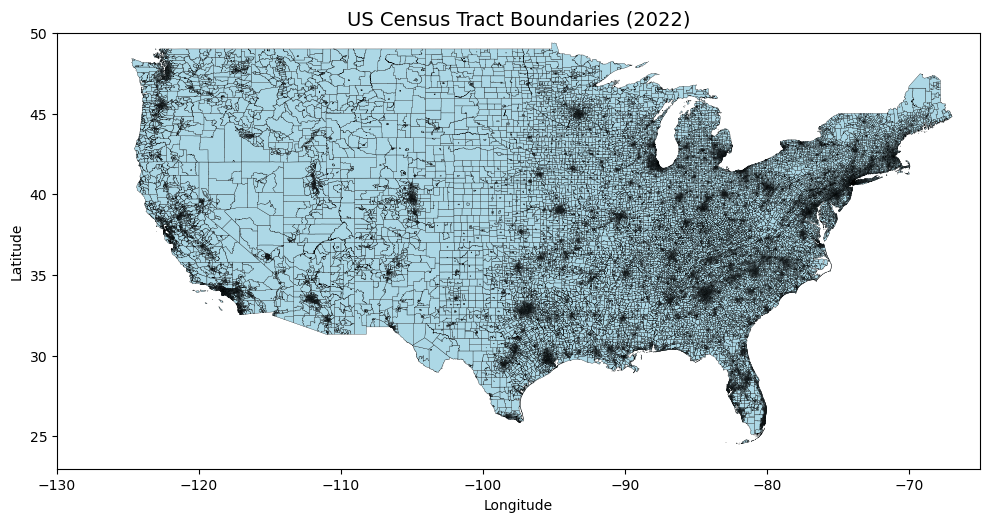

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

tract_geo.plot(
    ax=ax,
    color="lightblue",
    edgecolor="black",
    linewidth=0.2
)

ax.set_xlim(-130, -65)
ax.set_ylim(23, 50)
ax.set_title("US Census Tract Boundaries (2022)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [7]:
# Merge min distance data with tract data on HEROP_ID
# Both files are HeRoP outputs so HEROP_ID is the reliable common key
tract_w_dis = min_dis_data.merge(tract_data, on="HEROP_ID", how="left")
tract_w_dis.head()

,HEROP_ID,SutMinDis,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,FIPS,origin,SutCntDr,SutTmDr,SutTmDr2
0,140US01089011021,86.311559,1,89,11021,1400000US01089011021,1089011021,110.21,Census Tract 110.21,AL,Madison County,Alabama,CT,1089011021,1089011021,0,NaN,NaN
1,140US01095031200,75.532450,1,95,31200,1400000US01095031200,1095031200,312.00,Census Tract 312,AL,Marshall County,Alabama,CT,1095031200,1095031200,0,88.97,177.94
2,140US01073012401,43.154024,1,73,12401,1400000US01073012401,1073012401,124.01,Census Tract 124.01,AL,Jefferson County,Alabama,CT,1073012401,1073012401,0,NaN,NaN
3,140US01073003400,40.042051,1,73,3400,1400000US01073003400,1073003400,34.00,Census Tract 34,AL,Jefferson County,Alabama,CT,1073003400,1073003400,0,NaN,NaN
4,140US01073010402,32.005640,1,73,10402,1400000US01073010402,1073010402,104.02,Census Tract 104.02,AL,Jefferson County,Alabama,CT,1073010402,1073010402,0,NaN,NaN


In [8]:
# Extract 11-digit GEOID from HEROP_ID
# e.g. "140US01089011021" -> split on "US" -> take last part -> "01089011021"
# This ensures the script works even if GEOID is not pre-baked into the input files
tract_w_dis["GEOID"] = tract_w_dis["HEROP_ID"].str.split("US").str[-1].str.zfill(11)
crosswalk["TRACT"]   = crosswalk["TRACT"].astype(str).str.strip().str.zfill(11)

In [9]:
# Merge with tract shapefile to bring in spatial attributes
# This makes the script self-contained — spatial attributes are always sourced
# from the shapefile rather than relying on them being present in the input CSVs
tract_geo["GEOID"] = tract_geo["GEOID"].astype(str).str.zfill(11)
tract_w_dis = tract_w_dis.merge(tract_geo[["GEOID", "geometry"]], on="GEOID", how="left")
print(f"Tracts with geometry: {tract_w_dis['geometry'].notna().sum()} / {len(tract_w_dis)}")
tract_w_dis.head()

Tracts with geometry: 84306 / 85187


,HEROP_ID,SutMinDis,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,FIPS,origin,SutCntDr,SutTmDr,SutTmDr2,geometry
0,140US01089011021,86.311559,1,89,11021,1400000US01089011021,01089011021,110.21,Census Tract 110.21,AL,Madison County,Alabama,CT,1089011021,1089011021,0,NaN,NaN,"POLYGON ((-86.78678 34.67045, -86.78667 34.676..."
1,140US01095031200,75.532450,1,95,31200,1400000US01095031200,01095031200,312.00,Census Tract 312,AL,Marshall County,Alabama,CT,1095031200,1095031200,0,88.97,177.94,"POLYGON ((-86.17402 34.23036, -86.17375 34.230..."
2,140US01073012401,43.154024,1,73,12401,1400000US01073012401,01073012401,124.01,Census Tract 124.01,AL,Jefferson County,Alabama,CT,1073012401,1073012401,0,NaN,NaN,"POLYGON ((-86.90739 33.57448, -86.90562 33.575..."
3,140US01073003400,40.042051,1,73,3400,1400000US01073003400,01073003400,34.00,Census Tract 34,AL,Jefferson County,Alabama,CT,1073003400,1073003400,0,NaN,NaN,"POLYGON ((-86.91104 33.50274, -86.90335 33.512..."
4,140US01073010402,32.005640,1,73,10402,1400000US01073010402,01073010402,104.02,Census Tract 104.02,AL,Jefferson County,Alabama,CT,1073010402,1073010402,0,NaN,NaN,"POLYGON ((-86.99094 33.37425, -86.98185 33.385..."


In [10]:
# Diagnostic - check if GEOID keys match crosswalk TRACT keys
print("Sample tract_w_dis GEOIDs:")
print(tract_w_dis["GEOID"].head(10).tolist())

print("\nSample crosswalk TRACTs:")
print(crosswalk["TRACT"].head(10).tolist())

print("\nAny matches?")
common = set(tract_w_dis["GEOID"]).intersection(set(crosswalk["TRACT"]))
print(f"Number of matching keys: {len(common)}")
print("Sample matches:", list(common)[:5])

Sample tract_w_dis GEOIDs:
['01089011021', '01095031200', '01073012401', '01073003400', '01073010402', '01073005101', '01073000500', '01073010705', '01103001000', '01125011701']

Sample crosswalk TRACTs:
['36103158607', '72001956700', '72001956800', '72001956600', '72001956500', '72081958400', '72003430300', '72003430200', '72005400300', '72003430501']

Any matches?
Number of matching keys: 84055
Sample matches: ['06073008002', '05059020600', '53033032330', '48157670903', '36081014700']


In [11]:
# Merge the combined tract data with the ZIP crosswalk
# Left join retains all tracts — unmatched tracts get NaN for ZIP and ratio columns
merged = pd.merge(tract_w_dis, crosswalk, left_on="GEOID", right_on="TRACT", how="left")
merged.head()

,HEROP_ID,SutMinDis,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,...,SutTmDr2,geometry,ZIP,TRACT,USPS_ZIP_PREF_CITY,USPS_ZIP_PREF_STATE,RES_RATIO,BUS_RATIO,OTH_RATIO,TOT_RATIO
0,140US01089011021,86.311559,1,89,11021,1400000US01089011021,01089011021,110.21,Census Tract 110.21,AL,...,NaN,"POLYGON ((-86.78678 34.67045, -86.78667 34.676...",35758.0,01089011021,MADISON,AL,0.117186,0.222348,0.135870,0.127174
1,140US01095031200,75.532450,1,95,31200,1400000US01095031200,01095031200,312.00,Census Tract 312,AL,...,177.94,"POLYGON ((-86.17402 34.23036, -86.17375 34.230...",35950.0,01095031200,ALBERTVILLE,AL,0.000106,0.000000,0.000000,0.000092
2,140US01095031200,75.532450,1,95,31200,1400000US01095031200,01095031200,312.00,Census Tract 312,AL,...,177.94,"POLYGON ((-86.17402 34.23036, -86.17375 34.230...",35956.0,01095031200,BOAZ,AL,0.001441,0.000000,0.000000,0.001381
3,140US01095031200,75.532450,1,95,31200,1400000US01095031200,01095031200,312.00,Census Tract 312,AL,...,177.94,"POLYGON ((-86.17402 34.23036, -86.17375 34.230...",35957.0,01095031200,BOAZ,AL,0.327915,0.689057,0.674419,0.370558
4,140US01073012401,43.154024,1,73,12401,1400000US01073012401,01073012401,124.01,Census Tract 124.01,AL,...,NaN,"POLYGON ((-86.90739 33.57448, -86.90562 33.575...",35214.0,01073012401,BIRMINGHAM,AL,0.168812,0.202593,0.189516,0.171215


In [12]:
# Diagnostic - understand what's happening after crosswalk merge
print("Shape of merged dataframe:", merged.shape)
print("\nNull counts in key columns:")
print(merged[["SutTmDr", "SutTmDr2", "SutCntDr", "SutMinDis", "RES_RATIO"]].isnull().sum())

print("\nRows where RES_RATIO is NaN (unmatched tracts):", merged["RES_RATIO"].isna().sum())
print("Rows where RES_RATIO is NOT NaN (matched tracts):", merged["RES_RATIO"].notna().sum())

print("\nSample of merged data:")
print(merged[["GEOID", "TRACT", "ZIP", "RES_RATIO", "SutTmDr", "SutCntDr", "SutMinDis"]].head(10))

Shape of merged dataframe: (188742, 27)

Null counts in key columns:
SutTmDr      66722
SutTmDr2     66722
SutCntDr         0
SutMinDis        0
RES_RATIO     1132
dtype: int64

Rows where RES_RATIO is NaN (unmatched tracts): 1132
Rows where RES_RATIO is NOT NaN (matched tracts): 187610

Sample of merged data:
         GEOID        TRACT      ZIP  RES_RATIO  SutTmDr  SutCntDr  SutMinDis
0  01089011021  01089011021  35758.0   0.117186      NaN         0  86.311559
1  01095031200  01095031200  35950.0   0.000106    88.97         0  75.532450
2  01095031200  01095031200  35956.0   0.001441    88.97         0  75.532450
3  01095031200  01095031200  35957.0   0.327915    88.97         0  75.532450
4  01073012401  01073012401  35214.0   0.168812      NaN         0  43.154024
5  01073003400  01073003400  35218.0   0.290168      NaN         0  40.042051
6  01073010402  01073010402  35020.0   0.033274      NaN         0  32.005640
7  01073010402  01073010402  35022.0   0.050455      NaN        

In [13]:
# Drop rows where RES_RATIO is NaN
# These are tracts with no matching ZIP in the crosswalk
# Left join was intentional above to allow inspection of unmatched tracts first
merged = merged.dropna(subset=["RES_RATIO"])

In [14]:
# Multiply each tract-level metric by RES_RATIO (residential ratio)
# RES_RATIO = proportion of tract residents that fall in a given ZIP
# This weights each tract's contribution proportionally before aggregating to ZIP level
# SutTmDr  : Drive time (minutes) to nearest Substance Use Treatment facility
# SutTmDr2 : Drive time x2 (round trip)
# SutCntDr : Count of Substance Use Treatment facilities reachable within 30 min drive
# SutMinDis: Minimum distance (miles) to nearest Substance Use Treatment facility
merged["SutTmDr_wt"]   = merged["SutTmDr"]   * merged["RES_RATIO"]
merged["SutTmDr2_wt"]  = merged["SutTmDr2"]  * merged["RES_RATIO"]
merged["SutCntDr_wt"]  = merged["SutCntDr"]  * merged["RES_RATIO"]
merged["SutMinDis_wt"]  = merged["SutMinDis"] * merged["RES_RATIO"]

In [15]:
# Aggregate all weighted metrics to ZIP level by summing
# Also sum RES_RATIO per ZIP — serves as the total weight denominator
zip_agg = merged.groupby("ZIP").agg({
    "SutTmDr_wt"  : "sum",
    "SutTmDr2_wt" : "sum",
    "SutCntDr_wt"  : "sum",
    "SutMinDis_wt": "sum",
    "RES_RATIO"    : "sum"
}).reset_index()

In [16]:
# Compute final weighted averages
# Formula: weighted_avg = sum(metric * RES_RATIO) / sum(RES_RATIO)
zip_agg["SutTmDr"]   = zip_agg["SutTmDr_wt"]   / zip_agg["RES_RATIO"]
zip_agg["SutTmDr2"]  = zip_agg["SutTmDr2_wt"]  / zip_agg["RES_RATIO"]
zip_agg["SutCntDr"]  = zip_agg["SutCntDr_wt"]  / zip_agg["RES_RATIO"]
zip_agg["SutMinDis"] = zip_agg["SutMinDis_wt"] / zip_agg["RES_RATIO"]

In [17]:
# Fix ZIP format: stored as float (e.g. 6001.0) due to NaN rows during merge
# Convert to int -> string -> zero-pad to 5 digits to preserve leading zeros
zip_agg["ZIP"] = zip_agg["ZIP"].astype(int).astype(str).str.zfill(5)

# Construct ZCTA-level HEROP_ID using OEPS standard prefix "860US"
# Verified from OEPS GitHub: github.com/healthyregions/oeps (zcta-2025.csv)
# e.g. ZIP 60601 -> HEROP_ID 860US60601
zip_agg["HEROP_ID"] = "860US" + zip_agg["ZIP"].astype(str).str.zfill(5)

# Select final columns — HEROP_ID first per OEPS convention
# SutTmDr  : Weighted avg drive time to nearest Substance Use Treatment facility (minutes)
# SutTmDr2 : Weighted avg round-trip drive time (minutes)
# SutCntDr : Weighted avg count of facilities reachable within 30 min
# SutMinDis: Weighted avg minimum distance to nearest facility (miles)
result = zip_agg[["HEROP_ID", "ZIP", "SutTmDr", "SutTmDr2", "SutCntDr", "SutMinDis"]]
result.head()

,HEROP_ID,ZIP,SutTmDr,SutTmDr2,SutCntDr,SutMinDis
0,860US00501,00501,NaN,NaN,NaN,NaN
1,860US00601,00601,0.0,0.0,0.0,36.705673
2,860US00602,00602,0.0,0.0,0.0,63.468408
3,860US00603,00603,0.0,0.0,0.0,60.616593
4,860US00604,00604,0.0,0.0,0.0,59.694429


In [18]:
# Save final ZIP-level result to CSV
result.to_csv("SUT-ZIP25.csv", index=False)

In [19]:
!pip install openpyxl
result.to_excel("SUT-ZIP25.xlsx", index=False)
# Then format ZIP column as Text in Excel

In [20]:
# Visualization Setup
# geopandas  : read shapefiles and plot choropleth maps
# mapclassify: required for fisher_jenks classification scheme
# matplotlib : plotting
!pip install geopandas mapclassify matplotlib -q

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

print("Libraries loaded!")

Libraries loaded!


In [21]:
ZCTA_SHP_PATH = "zcta-2020-500k.shp"  # update this path
zcta_geo = gpd.read_file(ZCTA_SHP_PATH)

In [22]:
# Identify the ZIP key column in the ZCTA shapefile
zip_col = [c for c in zcta_geo.columns if "ZCTA" in c.upper() or c == "GEOID"][0]

# Ensure both sides are 5-digit zero-padded strings
zcta_geo[zip_col] = zcta_geo[zip_col].astype(str).str.zfill(5)
result["ZIP"]     = result["ZIP"].astype(str).str.zfill(5)

# Merge ZIP-level result with ZCTA geometry
zcta_merged = zcta_geo.merge(result, left_on=zip_col, right_on="ZIP", how="left")

/var/folders/69/5q2wfk010yqdww01frjhhm2c0000gn/T/ipykernel_3332/608728352.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result["ZIP"]     = result["ZIP"].astype(str).str.zfill(5)


In [23]:
zcta_merged

,ZCTA5CE20,AFFGEOID20,GEOID20,NAME20,LSAD20,ALAND20,AWATER20,HEROP_ID_x,minx,miny,...,maxy,BBOX,LABEL,geometry,HEROP_ID_y,ZIP,SutTmDr,SutTmDr2,SutCntDr,SutMinDis
0,15301,860Z200US15301,15301,15301,Z5,315861121,709775,860US15301,-80.368598,40.044189,...,40.282151,"-80.369,40.044,-80.131,40.282",15301,"POLYGON ((-80.3686 40.21895, -80.35493 40.2440...",860US15301,15301,78.007255,156.014511,0.000000,70.861726
1,15658,860Z200US15658,15658,15658,Z5,238683518,759690,860US15658,-79.343230,40.156005,...,40.357548,"-79.343,40.156,-79.055,40.358",15658,"POLYGON ((-79.34323 40.17201, -79.3375 40.1777...",860US15658,15658,0.000000,0.000000,0.000000,92.178226
2,15601,860Z200US15601,15601,15601,Z5,208874774,337008,860US15601,-79.669111,40.214076,...,40.450345,"-79.669,40.214,-79.435,40.45",15601,"POLYGON ((-79.66911 40.28912, -79.6626 40.2858...",860US15601,15601,0.000000,0.000000,0.000000,91.494210
3,17720,860Z200US17720,17720,17720,Z5,8797202,2822,860US17720,-77.230264,41.166952,...,41.193036,"-77.23,41.167,-77.177,41.193",17720,"POLYGON ((-77.23026 41.18926, -77.2249 41.1904...",860US17720,17720,0.000000,0.000000,0.000000,81.492894
4,18843,860Z200US18843,18843,18843,Z5,3620019,0,860US18843,-75.908030,41.787190,...,41.821749,"-75.908,41.787,-75.882,41.822",18843,"POLYGON ((-75.90554 41.79017, -75.90545 41.792...",860US18843,18843,0.000000,0.000000,0.000000,106.638996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33786,79837,860Z200US79837,79837,79837,Z5,2816585533,13321362,860US79837,-105.661092,31.745372,...,32.341740,"-105.661,31.745,-104.848,32.342",79837,"POLYGON ((-105.65967 32.22826, -105.65924 32.2...",860US79837,79837,0.000000,0.000000,0.000000,95.193937
33787,88338,860Z200US88338,88338,88338,Z5,410220035,0,860US88338,-105.524524,33.424905,...,33.651833,"-105.525,33.425,-105.243,33.652",88338,"POLYGON ((-105.52452 33.49586, -105.5228 33.49...",860US88338,88338,0.000000,0.000000,0.000000,83.537718
33788,40475,860Z200US40475,40475,40475,Z5,744211584,10950035,860US40475,-84.525643,37.622933,...,37.917546,"-84.526,37.623,-84.092,37.918",40475,"POLYGON ((-84.52564 37.7695, -84.52383 37.7707...",860US40475,40475,8.307784,16.615567,2.295391,3.782864
33789,99738,860Z200US99738,99738,99738,Z5,26066302603,325892484,860US99738,-144.247429,64.026902,...,66.142776,"-144.247,64.027,-141.001,66.143",99738,"POLYGON ((-144.24532 64.47211, -144.23448 64.4...",860US99738,99738,0.000000,0.000000,0.000000,384.810360


In [24]:
# Visualizing ZCTA
import matplotlib.pyplot as plt

def visualize_geographies_geodataframe(gdf, title="Geography Visualization", points_only=False):
    gdf = gdf.to_crs(epsg=4326).copy()

    fig, ax = plt.subplots(figsize=(10, 6))

    if points_only:
        gdf_proj = gdf.to_crs(epsg=5070)
        centroids = gdf_proj.centroid.to_crs(epsg=4326)
        ax.scatter(centroids.x, centroids.y, s=8, color="red", alpha=0.7)
    else:
        gdf.plot(ax=ax, color="lightblue", edgecolor="black", linewidth=0.2)

    ax.set_xlim(-130, -65)
    ax.set_ylim(23, 50)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title, fontsize=14)
    plt.show()

    return gdf

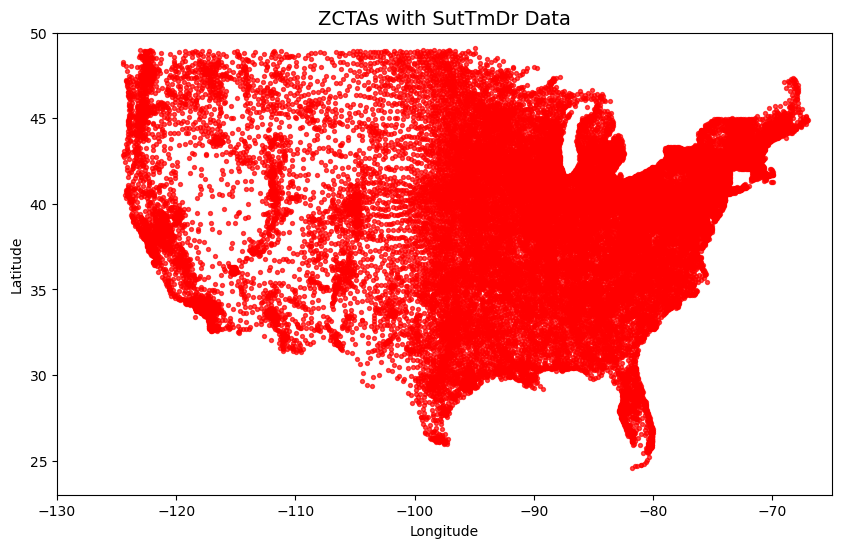

,ZCTA5CE20,AFFGEOID20,GEOID20,NAME20,LSAD20,ALAND20,AWATER20,HEROP_ID_x,minx,miny,...,maxy,BBOX,LABEL,geometry,HEROP_ID_y,ZIP,SutTmDr,SutTmDr2,SutCntDr,SutMinDis
0,15301,860Z200US15301,15301,15301,Z5,315861121,709775,860US15301,-80.368598,40.044189,...,40.282151,"-80.369,40.044,-80.131,40.282",15301,"POLYGON ((-80.3686 40.21895, -80.35493 40.2440...",860US15301,15301,78.007255,156.014511,0.000000,70.861726
1,15658,860Z200US15658,15658,15658,Z5,238683518,759690,860US15658,-79.343230,40.156005,...,40.357548,"-79.343,40.156,-79.055,40.358",15658,"POLYGON ((-79.34323 40.17201, -79.3375 40.1777...",860US15658,15658,0.000000,0.000000,0.000000,92.178226
2,15601,860Z200US15601,15601,15601,Z5,208874774,337008,860US15601,-79.669111,40.214076,...,40.450345,"-79.669,40.214,-79.435,40.45",15601,"POLYGON ((-79.66911 40.28912, -79.6626 40.2858...",860US15601,15601,0.000000,0.000000,0.000000,91.494210
3,17720,860Z200US17720,17720,17720,Z5,8797202,2822,860US17720,-77.230264,41.166952,...,41.193036,"-77.23,41.167,-77.177,41.193",17720,"POLYGON ((-77.23026 41.18926, -77.2249 41.1904...",860US17720,17720,0.000000,0.000000,0.000000,81.492894
4,18843,860Z200US18843,18843,18843,Z5,3620019,0,860US18843,-75.908030,41.787190,...,41.821749,"-75.908,41.787,-75.882,41.822",18843,"POLYGON ((-75.90554 41.79017, -75.90545 41.792...",860US18843,18843,0.000000,0.000000,0.000000,106.638996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33786,79837,860Z200US79837,79837,79837,Z5,2816585533,13321362,860US79837,-105.661092,31.745372,...,32.341740,"-105.661,31.745,-104.848,32.342",79837,"POLYGON ((-105.65967 32.22826, -105.65924 32.2...",860US79837,79837,0.000000,0.000000,0.000000,95.193937
33787,88338,860Z200US88338,88338,88338,Z5,410220035,0,860US88338,-105.524524,33.424905,...,33.651833,"-105.525,33.425,-105.243,33.652",88338,"POLYGON ((-105.52452 33.49586, -105.5228 33.49...",860US88338,88338,0.000000,0.000000,0.000000,83.537718
33788,40475,860Z200US40475,40475,40475,Z5,744211584,10950035,860US40475,-84.525643,37.622933,...,37.917546,"-84.526,37.623,-84.092,37.918",40475,"POLYGON ((-84.52564 37.7695, -84.52383 37.7707...",860US40475,40475,8.307784,16.615567,2.295391,3.782864
33789,99738,860Z200US99738,99738,99738,Z5,26066302603,325892484,860US99738,-144.247429,64.026902,...,66.142776,"-144.247,64.027,-141.001,66.143",99738,"POLYGON ((-144.24532 64.47211, -144.23448 64.4...",860US99738,99738,0.000000,0.000000,0.000000,384.810360


In [25]:
zcta_with_data = zcta_merged[zcta_merged["SutTmDr"].notna()].copy()

visualize_geographies_geodataframe(
    zcta_with_data,
    title="ZCTAs with SutTmDr Data",
    points_only=True
)

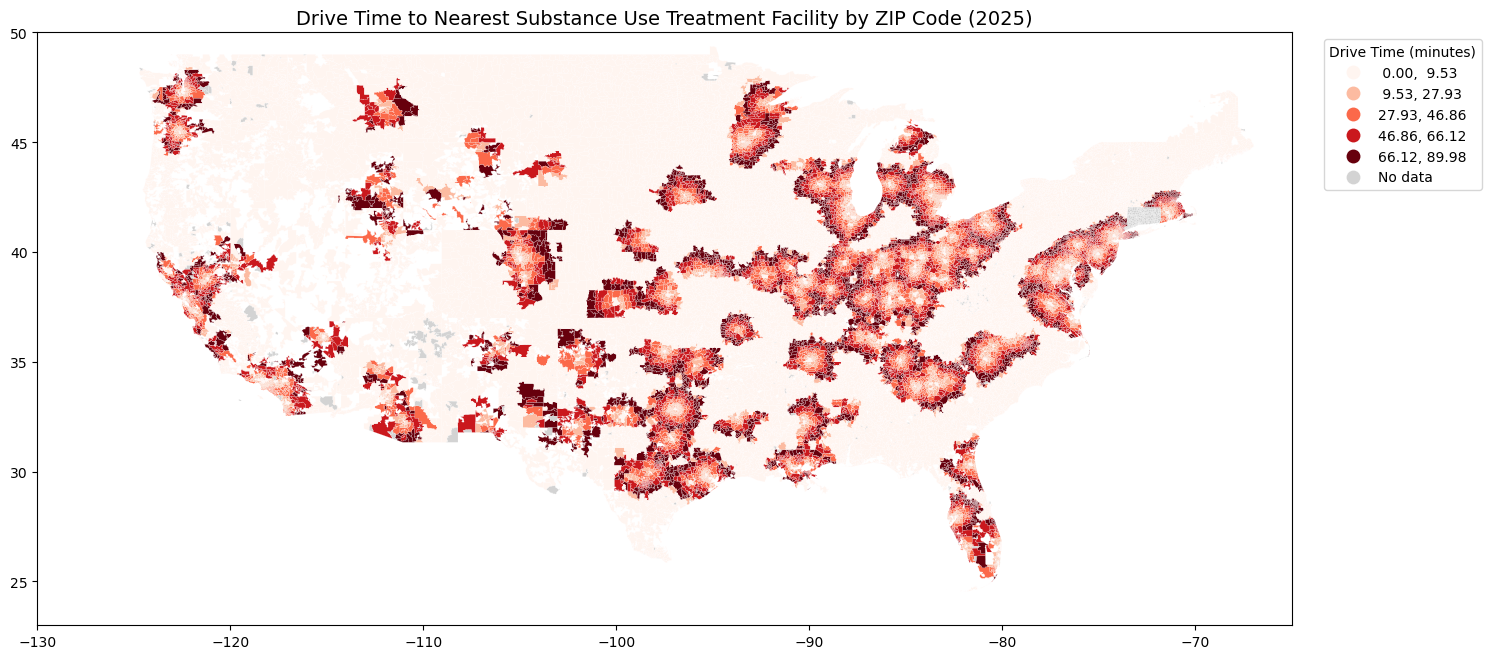

In [26]:
# Plot choropleth
fig, ax = plt.subplots(figsize=(15, 9))

zcta_merged.plot(
    ax=ax,
    column="SutTmDr",
    cmap="Reds",
    scheme="fisher_jenks",
    k=5,
    edgecolor="white",
    linewidth=0.1,
    legend=True,
    legend_kwds={
        "title": "Drive Time (minutes)",
        "loc": "upper left",
        "bbox_to_anchor": (1.02, 1.0),
        "frameon": True
    },
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

ax.set_xlim(-130, -65)
ax.set_ylim(23, 50)
ax.set_title("Drive Time to Nearest Substance Use Treatment Facility by ZIP Code (2025)", fontsize=14)
plt.tight_layout()
plt.show()